# Competitive Consensus Engine

Imagine an enterprise agent tasked with reviewing a critical financial transaction or legal contract for anomalies.<br>
Instead of relying on one model prompt (which has a high risk of bias or hallucination), this architecture works like a high-stakes corporate boardroom:

1. **The Orchestrator:** Receives a single, complex request. It dynamically clones the task and pushes it to an array of different expert analyst models concurrently.
2. **The Map Workers (`map_doc`):** Run in parallel. Each worker is injected with a different specialized system persona—for example, 
   - **The Aggressive Risk Auditor**
   - **The Conservative Compliance Lawyer**
   - **The Data Security Specialist**<br>
  They evaluate the text independently from their unique domain perspective.
1. **The State Buffer Layer:** LangGraph traps their individual findings inside an `operator.add` list accumulator as they finish executing, preventing state overwrite.
2. **The Reducer (`reducer`):** Acts as a **Blind Supreme Court Judge**. It cross-checks all three conflicting expert logs, flags points of disagreement, strips out redundant noise, and distills the collective intelligence into a single authoritative risk verdict.

In [ ]:
import os
import time
from typing import TypedDict, List, Dict, Annotated
from operator import add
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send, Command
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI


In [12]:
class ConsensusState(TypedDict):
    """The global ledger tracking our competitive consensus workflow."""
    target_contract: str                         # The core proposal/text to evaluate
    expert_personas: List[Dict[str, str]]        # Names and prompt instructions for parallel agents
    raw_expert_opinions: Annotated[List[Dict[str, str]], add]  # Accumulator List
    final_verdict: Dict[str, str]                # The final consolidated judgment

class ExpertState(TypedDict):
    """The private sandbox state provided to each parallel expert agent."""
    contract_text: str
    persona_name: str
    persona_prompt: str

In [13]:
# Initialize LLM Engine (Ensure GROQ_API_KEY is available in your environment)
# llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.2)

def get_groq_llm() -> ChatOpenAI:
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.7,
        max_tokens=2000
    )

llm = get_groq_llm()

In [14]:
def orchestrator(state: ConsensusState) -> Command:
    print("1. ORCHESTRATOR NODE -> INSPECTING INCOMING GLOBAL STATE")
    for key, value in state.items():
        if key == "target_contract":
            print(f"👉 state['target_contract']: {value[:120]}... [Truncated for readability]")
        else:
            print(f"👉 state['{key}']: {value}")
    print("-" * 60)

    contract = state["target_contract"]
    experts = state.get("expert_personas", []) or []

    sends = []
    print(f"GENERATED IN-FLIGHT PACKET FOR WORKER: Send(goto='expert_analyst')")
    for ex in experts:
        payload: ExpertState = {
            "contract_text": contract,
            "persona_name": ex["name"],
            "persona_prompt": ex["prompt"]
        }
        sends.append(Send("expert_analyst", payload))
        print(f"   ↳ Assigned Identity: {payload['persona_name']}")

    print("\nDispatched parallel worker nodes simultaneously...")
    print("-" * 60)
    return Command(update={}, goto=sends)

In [15]:
def expert_analyst(state: ExpertState) -> Dict[str, List[Dict[str, str]]]:
    print(f"2. MAP WORKER NODE -> INSTANTIATING SANDBOX FOR: {state.get('persona_name')}")
    print(f"local_sandbox_state['persona_name']: {state.get('persona_name')}")
    print(f"local_sandbox_state['persona_prompt']: {state.get('persona_prompt')}")
    print("-" * 60)

    system_instruction = (
        f"You are {state['persona_name']}. Perform your evaluation strictly according "
        f"to this perspective: {state['persona_prompt']}. Be concise (max 2-3 sentences)."
    )

    response = llm.invoke([
        SystemMessage(content=system_instruction),
        HumanMessage(content=f"Analyze this document/case: {state['contract_text']}")
    ])

    opinion_payload = {
        "expert_name": state["persona_name"],
        "opinion": response.content.strip()
    }

    output_payload = {"raw_expert_opinions": [opinion_payload]}
    print(f"WORKER TERMINATION ({state['persona_name']}) -> RETURNING PAYLOAD TO ENGINE")
    return output_payload

In [16]:
def judge_reducer(state: ConsensusState) -> Dict[str, Dict[str, str]]:
    print("\n\n3. REDUCER NODE -> SYNCHRONIZATION BARRIER CLEARED")
    print(f"👉 Current Total Elements inside state['raw_expert_opinions']: {len(state.get('raw_expert_opinions', []))}")
    print("-" * 60)

    opinions_list = state.get("raw_expert_opinions", []) or []
    compiled_briefs = ""
    for op in opinions_list:
        compiled_briefs += f"\n=== OPINION BY: {op['expert_name']} ===\n{op['opinion']}\n"

    judge_instruction = (
        "You are the Supreme Consensus Arbiter. Review the conflicting perspectives and findings presented. "
        "Highlight clear friction points, align mutual items of agreement, and render a definitive, comprehensive final roadmap verdict."
    )

    response = llm.invoke([
        SystemMessage(content=judge_instruction),
        HumanMessage(content=f"Expert Briefs:\n{compiled_briefs}\n\nOriginal Input Case:\n{state['target_contract']}")
    ])

    reducer_output = {
        "final_verdict": {
            "summary_of_deliberations": f"Compiled {len(opinions_list)} briefs.",
            "ruling": response.content.strip()
        }
    }

    print("REDUCER TERMINATION -> WRITING OVERWRITE PAYLOAD BACK TO STATE:")
    return reducer_output

In [17]:
def build_consensus_graph() -> StateGraph:
    builder = StateGraph(ConsensusState)
    builder.add_node("orchestrator", orchestrator)
    builder.add_node("expert_analyst", expert_analyst)
    builder.add_node("judge_reducer", judge_reducer)

    builder.add_edge(START, "orchestrator")
    builder.add_edge("expert_analyst", "judge_reducer")
    builder.add_edge("judge_reducer", END)

    graph = builder.compile(checkpointer=MemorySaver())
    print(graph)
    return graph

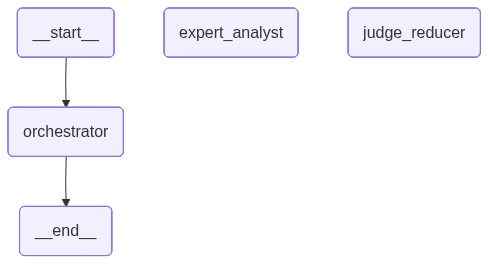

In [18]:
# Compile the graph structure once
graph = build_consensus_graph()
graph

In [19]:
if __name__ == "__main__":
    # NEW SCENARIO 1: MEDICAL DIAGNOSTIC CONSENSUS PANEL
    medical_case = (
        "Patient Case File: A 45-year-old male presents with chronic fatigue, unexplained weight gain, "
        "mild bradycardia (slow heart rate), and persistent cold intolerance. However, recent acute laboratory "
        "panels also show slightly elevated liver enzymes and intermittent joint inflammation in both knees."
    )

    medical_panel = [
        {
            "name": "Endocrinology Specialist",
            "prompt": "Evaluate for thyroid abnormalities, metabolic disorders, and hormone imbalances."
        },
        {
            "name": "Rheumatologist",
            "prompt": "Analyze symptoms from an autoimmune perspective, focusing on systemic inflammation and joint wear."
        },
        {
            "name": "General Internist / Pharmacologist",
            "prompt": "Look for liver stress indicators, potential environmental toxins, or common drug interactions."
        }
    ]

    medical_input: ConsensusState = {
        "target_contract": medical_case,
        "expert_personas": medical_panel,
        "raw_expert_opinions": [],
        "final_verdict": {}
    }

    print("\n" + "#"*80)
    print("⚕️  RUNNING SCENARIO 1: MEDICAL DIAGNOSTIC CONSENSUS PANEL")
    print("#"*80)

    config_med = {"configurable": {"thread_id": "medical_session"}}
    graph.invoke(medical_input, config=config_med)

    # Extract final snapshot for Scenario 1
    med_snapshot = graph.get_state(config_med)
    print("\n🩺 === MEDICAL PANELS FINAL CONSOLIDATED DIAGNOSIS ===")
    print(med_snapshot.values["final_verdict"]["ruling"])


################################################################################
⚕️  RUNNING SCENARIO 1: MEDICAL DIAGNOSTIC CONSENSUS PANEL
################################################################################
1. ORCHESTRATOR NODE -> INSPECTING INCOMING GLOBAL STATE
👉 state['target_contract']: Patient Case File: A 45-year-old male presents with chronic fatigue, unexplained weight gain, mild bradycardia (slow hea... [Truncated for readability]
👉 state['expert_personas']: [{'name': 'Endocrinology Specialist', 'prompt': 'Evaluate for thyroid abnormalities, metabolic disorders, and hormone imbalances.'}, {'name': 'Rheumatologist', 'prompt': 'Analyze symptoms from an autoimmune perspective, focusing on systemic inflammation and joint wear.'}, {'name': 'General Internist / Pharmacologist', 'prompt': 'Look for liver stress indicators, potential environmental toxins, or common drug interactions.'}]
👉 state['raw_expert_opinions']: []
👉 state['final_verdict']: {}
--------------------

In [20]:
if __name__ == "__main__":
    # NEW SCENARIO 2: SOFTWARE CLOUD ARCHITECTURE DESIGN REVIEW
    architecture_proposal = (
        "System Architecture Blueprint: We propose migrating our core database from an on-premise relational setup "
        "to a globally distributed, multi-region NoSQL cluster deployed on a public cloud provider. "
        "Data synchronization will happen asynchronously across 4 global zones to maximize write speed. "
        "To save operational costs, network transport layer encryption (TLS) will be offloaded to edge routers only."
    )

    architecture_panel = [
        {
            "name": "Principal Performance Engineer",
            "prompt": "Focus heavily on scaling limitations, system write speeds, and multi-region latency optimization."
        },
        {
            "name": "Chief Info Security Officer (CISO)",
            "prompt": "Identify vulnerabilities regarding edge TLS encryption offloading and public cloud exposures."
        },
        {
            "name": "FinOps Budget Controller",
            "prompt": "Audit the cost implications of running 4 distinct globally mirrored distributed clusters."
        }
    ]

    architecture_input: ConsensusState = {
        "target_contract": architecture_proposal,
        "expert_personas": architecture_panel,
        "raw_expert_opinions": [],
        "final_verdict": {}
    }

    print("\n" + "#"*80)
    print("💻 RUNNING SCENARIO 2: CLOUD ARCHITECTURE DESIGN REVIEW")
    print("#"*80)

    config_arch = {"configurable": {"thread_id": "architecture_session"}}
    graph.invoke(architecture_input, config=config_arch)

    # Extract final snapshot for Scenario 2
    arch_snapshot = graph.get_state(config_arch)
    print("\n🏗️  === INFRASTRUCTURE REVIEW FINAL VERDICT ===")
    print(arch_snapshot.values["final_verdict"]["ruling"])


################################################################################
💻 RUNNING SCENARIO 2: CLOUD ARCHITECTURE DESIGN REVIEW
################################################################################
1. ORCHESTRATOR NODE -> INSPECTING INCOMING GLOBAL STATE
👉 state['target_contract']: System Architecture Blueprint: We propose migrating our core database from an on-premise relational setup to a globally ... [Truncated for readability]
👉 state['expert_personas']: [{'name': 'Principal Performance Engineer', 'prompt': 'Focus heavily on scaling limitations, system write speeds, and multi-region latency optimization.'}, {'name': 'Chief Info Security Officer (CISO)', 'prompt': 'Identify vulnerabilities regarding edge TLS encryption offloading and public cloud exposures.'}, {'name': 'FinOps Budget Controller', 'prompt': 'Audit the cost implications of running 4 distinct globally mirrored distributed clusters.'}]
👉 state['raw_expert_opinions']: []
👉 state['final_verdict']: {}
-